<a href="https://colab.research.google.com/github/dierazoc-sys/SD-y-C/blob/main/SIMULACION_1_SD_y_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sistema masa- resorte-amortiguador**

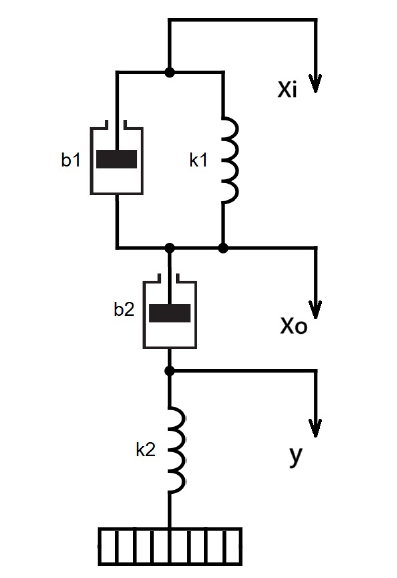

**funcion de transferencia de lazo abierto con excitaciones de tipo impulso y escalón .**

$$
\frac{X_o(s)}{X_i(s)} = \frac{b_1 s + k_1}{(b_1 + b_2)s + (k_1 + k_2)}
$$

Para poder simular asignamos valores:

𝑘1=10𝑁/𝑚

𝑘2=15𝑁/𝑚

𝑏1=2𝑁𝑠/𝑚

𝑏2=3𝑁𝑠/𝑚

Sustituimos los valores en la funcion de transferencia


$$
G(s) = \frac{2s+10}{s(2 + 3)+(10 + 15)}
$$


**funcion de transferencia de lazo abierto**


$$
Xₒ(s) = G(s)Xᵢ(s)
$$

➤ Entrada escalón:$$𝑋𝑖(𝑠)=\frac{1}{s}$$
Respuesta a escalon unitario

$$X_o(s) = G(s) \cdot \frac{1}{s} = \frac{10 + 2s}{25 + 5s} \cdot \frac{1}{s}$$

➤ Entrada impulso:$$𝑋𝑖(𝑠)={1}$$
Respuesta a impulso
$$G(s) = \frac{10 + 2s}{25 + 5s}$$


**Funcion de transferencia con realimentacion unitaria**

$$T(s) = \frac{G(s)}{1 + G(s)}$$

sustituimos G(s):
$$T(s) = \frac{\frac{10 + 2s}{25 + 5s}}{1 + \frac{10 + 2s}{25 + 5s}}$$

simplificamos:
$$T(s) = \frac{10 + 2s}{(25 + 5s) + (10 + 2s)}$$

$$T(s) = \frac{10 + 2s}{35 + 7s}$$

**Respuesta en lazo cerrado**

➤ Entrada escalón:$$𝑋𝑖(𝑠)=\frac{1}{s}$$
Respuesta a escalon unitario

$$X_o(s) = \frac{10 + 2s}{35 + 7s} \cdot \frac{1}{s} = \frac{2(5 + s)}{7(5 + s)} \cdot \frac{1}{s} = \frac{2}{7s}$$

➤ Entrada impulso:$$𝑋𝑖(𝑠)={1}$$
Respuesta a impulso
$$\
X_o(s) = T(s) = \frac{10 + 2s}{35 + 7s}
\
$$



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 10.9 MB/s eta 0:00:00
Función de transferencia en lazo abierto:
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  2 s + 10
  --------
  5 s + 25
Función de transferencia en lazo cerrado:
<TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  2 s + 10
  --------
  7 s + 35


/usr/local/lib/python3.13/dist-packages/control/pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/control/timeresp.py:2015: UserWarning: System has direct feedthrough: `D != 0`. The infinite impulse at `t=0` does not appear in the output.
Results may be meaningless!
  warnings.warn("System has direct feedthrough: `D != 0`. The "


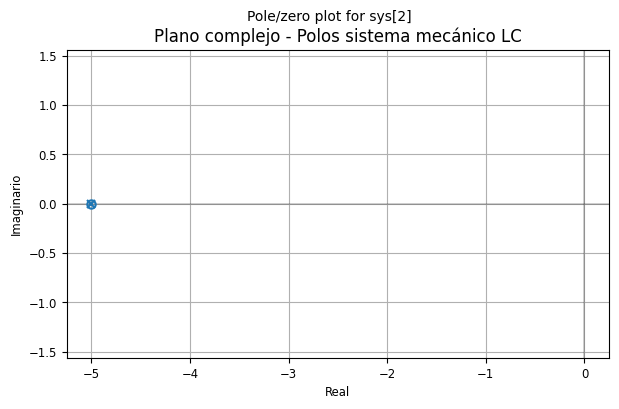

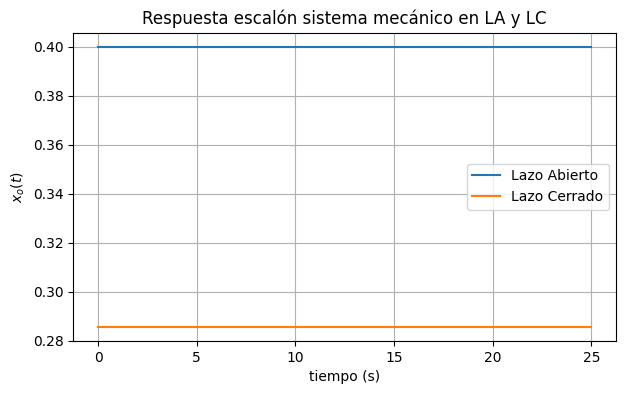

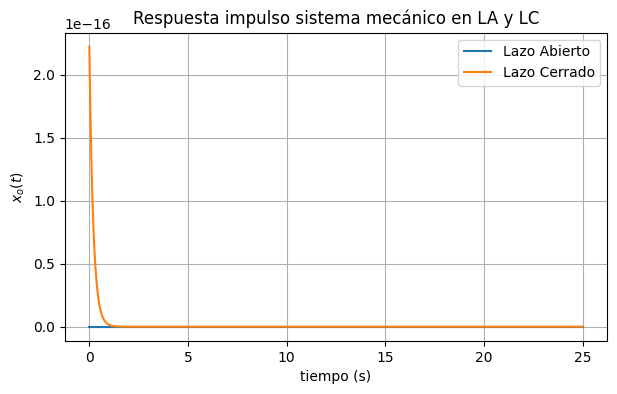

In [ ]:
# Funciones matemáticas
import numpy as np
# Funciones para gráficos
import matplotlib.pyplot as plt
# Funciones tipo Matlab
!pip install control
from control.matlab import *

# Definición de la función de transferencia en lazo abierto
num = [2, 10]
den = [5, 25]
ftla = tf(num, den)
print("Función de transferencia en lazo abierto:")
print(ftla)

# Función de transferencia en lazo cerrado (feedback unitario)
ftlc = feedback(ftla, 1)
print("Función de transferencia en lazo cerrado:")
print(ftlc)


# Gráfico de polos y ceros en lazo cerrado
plt.figure(1, figsize=[7, 4])
pzmap(ftlc)
plt.xlabel('Real')
plt.ylabel('Imaginario')
plt.title('Plano complejo - Polos sistema mecánico LC')
plt.grid()

# Respuesta al escalón en LA y LC
plt.figure(2, figsize=[7, 4])
yout, T = step(ftla, T=np.linspace(0, 25, 500))
yout1, T1 = step(ftlc, T=np.linspace(0, 25, 500))
plt.plot(T.T, yout.T, label='Lazo Abierto')
plt.plot(T1.T, yout1.T, label='Lazo Cerrado')
plt.xlabel('tiempo (s)')
plt.ylabel('$x_o(t)$')
plt.title('Respuesta escalón sistema mecánico en LA y LC')
plt.legend()
plt.grid()


# Respuesta al impulso en LA y LC
plt.figure(3, figsize=[7, 4])
yout, T = impulse(ftla, T=np.linspace(0, 25, 500))
yout1, T1 = impulse(ftlc, T=np.linspace(0, 25, 500))
plt.plot(T.T, yout.T, label='Lazo Abierto')
plt.plot(T1.T, yout1.T, label='Lazo Cerrado')
plt.xlabel('tiempo (s)')
plt.ylabel('$x_o(t)$')
plt.title('Respuesta impulso sistema mecánico en LA y LC')
plt.legend()
plt.grid()

plt.show()


# **Circuito RC**

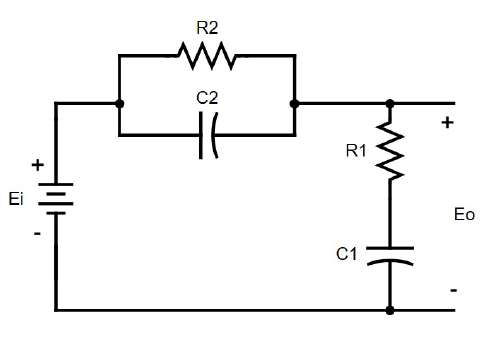

**funcion de transferencia de lazo abierto con excitaciones de tipo impulso y escalón .**



$$
\frac{E_o(s)}{E_i(s)} = \frac{1}{sC1R1 + 1}
$$

**# Valores ejemplo de C1 y R1**

𝐶1=1×10−6 F


𝑅1=1×10 3Ω

$$G_2(s) = \frac{1}{sC_1R_1 + 1} = \frac{1}{s(10^3 \cdot 10^{-6}) + 1} = \frac{1}{0.001s + 1}$$


➤ Entrada escalón:$$E_i(s)=\frac{1}{s}$$
Respuesta al escalon unitrio

$$\
E_o(s) = G(s) \cdot E_i(s) = \left( \frac{1}{sC_1 R_1 + 1} \right) \cdot \left( \frac{1}{s} \right) = \frac{1}{s(sC_1 R_1 + 1)}
\
$$

➤ Entrada impulso:$$E_i(s)={1}$$
Respuesta al impulso
$$\
E_o(s) = G(s) \cdot E_i(s) = \frac{1}{s C_1 R_1 + 1}
\
$$


**Funcion de transferencia de lazo cerrado con realimentacion unitaria**

$$T(s) = \frac{G(s)}{1+G(s)} = \frac{\frac{1}{sC_1R_1 + 1}}{1 + \frac{1}{sC_1R_1 + 1}} = \frac{1}{sC_1R_1 + 2}$$



➤ Entrada escalón:$$E_i(s)=\frac{1}{s}$$

Respuesta al escalon unitario
$$E_o(s) = T(s) \cdot E_i(s) = \frac{1}{sC_1R_1 + 2} \cdot \frac{1}{s} = \frac{1}{s(sC_1R_1 + 2)}$$
➤ Entrada impulso:$$E_i(s)={1}$$

Respuesta al impulso
$$E_o(s) = T(s) \cdot E_i(s) = \frac{1}{sC_1R_1 + 2}$$

Función de transferencia en lazo abierto (G(s)):
<TransferFunction>: sys[7]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       1
  -----------
  0.001 s + 1
Función de transferencia en lazo cerrado (feedback 1):
<TransferFunction>: sys[9]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       1
  -----------
  0.001 s + 2


/usr/local/lib/python3.13/dist-packages/control/pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


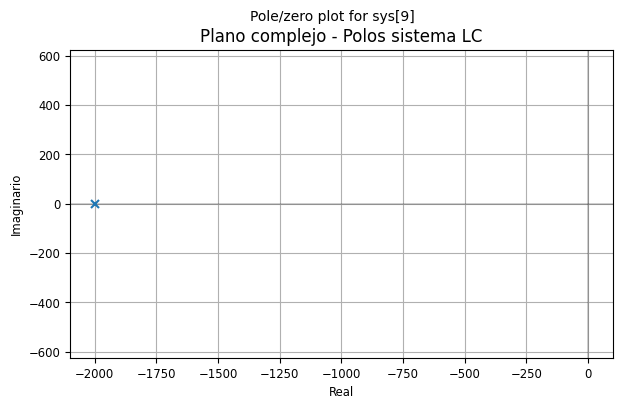

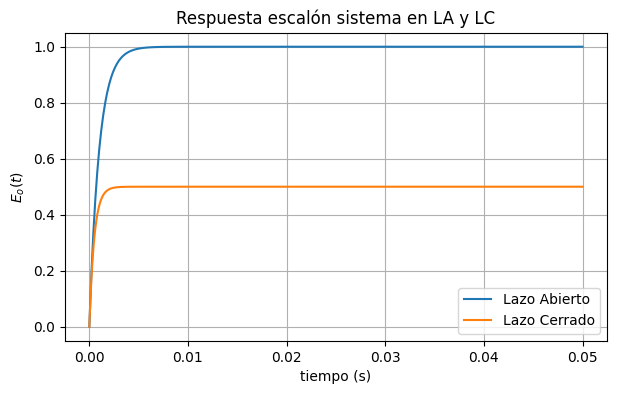

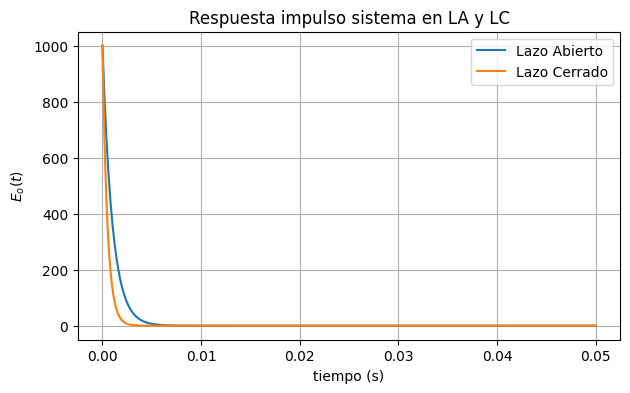

In [ ]:
# Funciones matemáticas
import numpy as np
# Funciones para gráficos
import matplotlib.pyplot as plt
# Funciones tipo Matlab
!pip install control
from control.matlab import *

# Valores ejemplo de C1 y R1
C1 = 1e-6  # 1 microfaradio
R1 = 1e3   # 1 kiloohm

# Definición de la función de transferencia en lazo abierto
num = [1]
den = [C1 * R1, 1]
ftla = tf(num, den)
print("Función de transferencia en lazo abierto (G(s)):")
print(ftla)

# Función de transferencia en lazo cerrado (feedback unitario)
ftlc = feedback(ftla, 1)
print("Función de transferencia en lazo cerrado (feedback 1):")
print(ftlc)

# Gráfico de polos y ceros en lazo cerrado
plt.figure(1, figsize=[7, 4])
pzmap(ftlc)
plt.xlabel('Real')
plt.ylabel('Imaginario')
plt.title('Plano complejo - Polos sistema LC')
plt.grid()

# Respuesta al escalón en LA y LC
plt.figure(2, figsize=[7, 4])
T_sim = np.linspace(0, 0.05, 500)
yout, T = step(ftla, T=T_sim)
yout1, T1 = step(ftlc, T=T_sim)
plt.plot(T.T, yout.T, label='Lazo Abierto')
plt.plot(T1.T, yout1.T, label='Lazo Cerrado')
plt.xlabel('tiempo (s)')
plt.ylabel('$E_o(t)$')
plt.title('Respuesta escalón sistema en LA y LC')
plt.legend()
plt.grid()

# Respuesta al impulso en LA y LC
plt.figure(3, figsize=[7, 4])
yout, T = impulse(ftla, T=T_sim)
yout1, T1 = impulse(ftlc, T=T_sim)
plt.plot(T.T, yout.T, label='Lazo Abierto')
plt.plot(T1.T, yout1.T, label='Lazo Cerrado')
plt.xlabel('tiempo (s)')
plt.ylabel('$E_o(t)$')
plt.title('Respuesta impulso sistema en LA y LC')
plt.legend()
plt.grid()

plt.show()


# **Funcion de transferencia de la planta de la ecuacion (13).**


$$
[G(s) = \frac{0.3188}{s^2 + 1.143s + 0.3188}
$$



Función de transferencia en lazo abierto (G(s)):
<TransferFunction>: sys[14]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          0.3188
  ----------------------
  s^2 + 1.143 s + 0.3188
Función de transferencia en lazo cerrado (feedback 1):
<TransferFunction>: sys[16]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          0.3188
  ----------------------
  s^2 + 1.143 s + 0.6376


/usr/local/lib/python3.13/dist-packages/control/pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


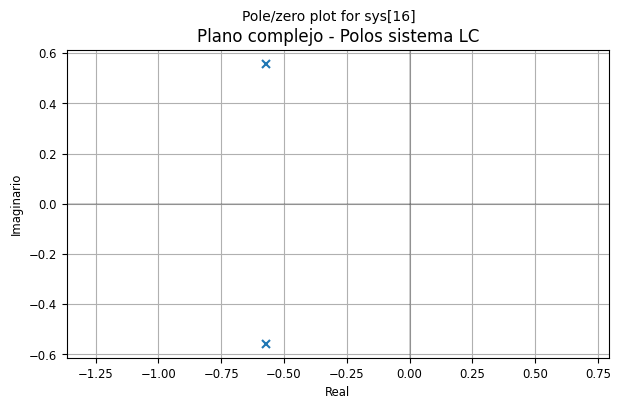

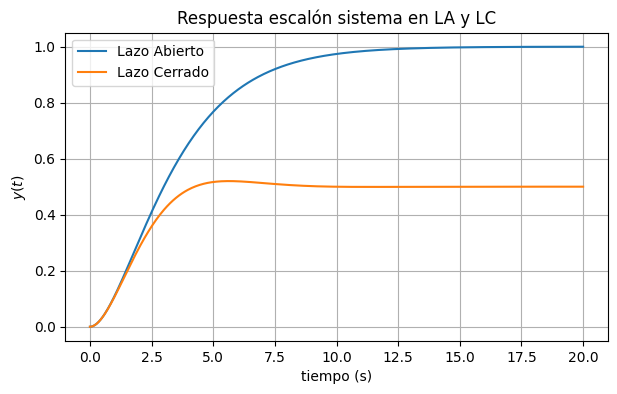

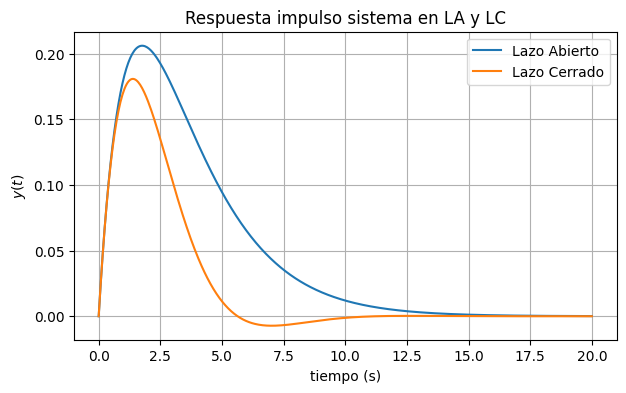

In [ ]:
# Funciones matemáticas
import numpy as np
# Funciones para gráficos
import matplotlib.pyplot as plt
# Funciones tipo Matlab
!pip install control
from control.matlab import *

# Definición de la función de transferencia en lazo abierto
num = [0.3188]
den = [1, 1.143, 0.3188]
ftla = tf(num, den)
print("Función de transferencia en lazo abierto (G(s)):")
print(ftla)

# Función de transferencia en lazo cerrado (feedback unitario)
ftlc = feedback(ftla, 1)
print("Función de transferencia en lazo cerrado (feedback 1):")
print(ftlc)

# Gráfico de polos y ceros en lazo cerrado
plt.figure(1, figsize=[7, 4])
pzmap(ftlc)
plt.xlabel('Real')
plt.ylabel('Imaginario')
plt.title('Plano complejo - Polos sistema LC')
plt.grid()

# Respuesta al escalón en LA y LC
plt.figure(2, figsize=[7, 4])
yout, T = step(ftla, T=np.linspace(0, 20, 500))
yout1, T1 = step(ftlc, T=np.linspace(0, 20, 500))
plt.plot(T.T, yout.T, label='Lazo Abierto')
plt.plot(T1.T, yout1.T, label='Lazo Cerrado')
plt.xlabel('tiempo (s)')
plt.ylabel('$y(t)$')
plt.title('Respuesta escalón sistema en LA y LC')
plt.legend()
plt.grid()

# Respuesta al impulso en LA y LC
plt.figure(3, figsize=[7, 4])
yout, T = impulse(ftla, T=np.linspace(0, 20, 500))
yout1, T1 = impulse(ftlc, T=np.linspace(0, 20, 500))
plt.plot(T.T, yout.T, label='Lazo Abierto')
plt.plot(T1.T, yout1.T, label='Lazo Cerrado')
plt.xlabel('tiempo (s)')
plt.ylabel('$y(t)$')
plt.title('Respuesta impulso sistema en LA y LC')
plt.legend()
plt.grid()

plt.show()
